# Prediksi Kadar N02 di Daerah Bali

### Latar Belakang

Perkembangan sektor transportasi dan pariwisata yang pesat di Provinsi Bali secara tidak langsung mendorong peningkatan emisi gas buang ke atmosfer. Salah satu gas yang cukup berbahaya adalah Nitrogen Dioksida (NO₂), yang banyak dihasilkan dari kendaraan bermotor dan aktivitas pembakaran lainnya. Keberadaan gas ini dalam jumlah tinggi dapat menurunkan kualitas udara serta berdampak buruk bagi kesehatan manusia, terutama pada sistem pernapasan.

Untuk memahami kondisi tersebut secara lebih akurat, diperlukan data yang mampu menggambarkan sebaran NO₂ secara luas dan berkelanjutan. Pemanfaatan data satelit seperti Sentinel-5P memungkinkan pengamatan kualitas udara tanpa batas wilayah secara langsung. Dengan bantuan platform OpenEO, proses pengambilan data (crawling) dapat dilakukan secara sistematis sehingga informasi yang diperoleh dapat digunakan sebagai dasar dalam analisis kualitas udara di wilayah Bali.

### 1. Pengumpulan Data
Data yang digunakan dalam penelitian ini berupa konsentrasi Nitrogen Dioksida (NO₂) harian di wilayah Provinsi Bali yang diperoleh dari satelit Sentinel-5P melalui platform OpenEO.

Proses pengambilan data dimulai dengan pembuatan akun pada Copernicus Data Space, kemudian dilakukan autentikasi menggunakan OpenEO di Python agar sistem dapat terhubung dan mengakses data satelit sesuai kebutuhan.


Kita install terlebih dahulu openoneo:

In [1]:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import openeo

In [5]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=LBFK-ULJX 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Akses link autentikasi yang tersedia lalu lakukan login dengan akun Copernicus Anda.

In [6]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.09, -6.89],
            [112.68, -6.89],
            [112.68, -7.20],
            [113.09, -7.20],
            [113.09, -6.89],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

AOI (Area of Interest) merupakan wilayah yang menjadi fokus dalam pengambilan data penelitian. Pada penelitian ini, area yang digunakan dibentuk berdasarkan koordinat yang diperoleh dalam format GeoJSON sehingga menghasilkan batas wilayah sesuai dengan daerah yang ditentukan.

Untuk menentukan koordinat tersebut, dapat kunjungi website ini

https://geojson.io/?map=4.15/-8.4/114.88#map=14.8/-7.04732/112.69463

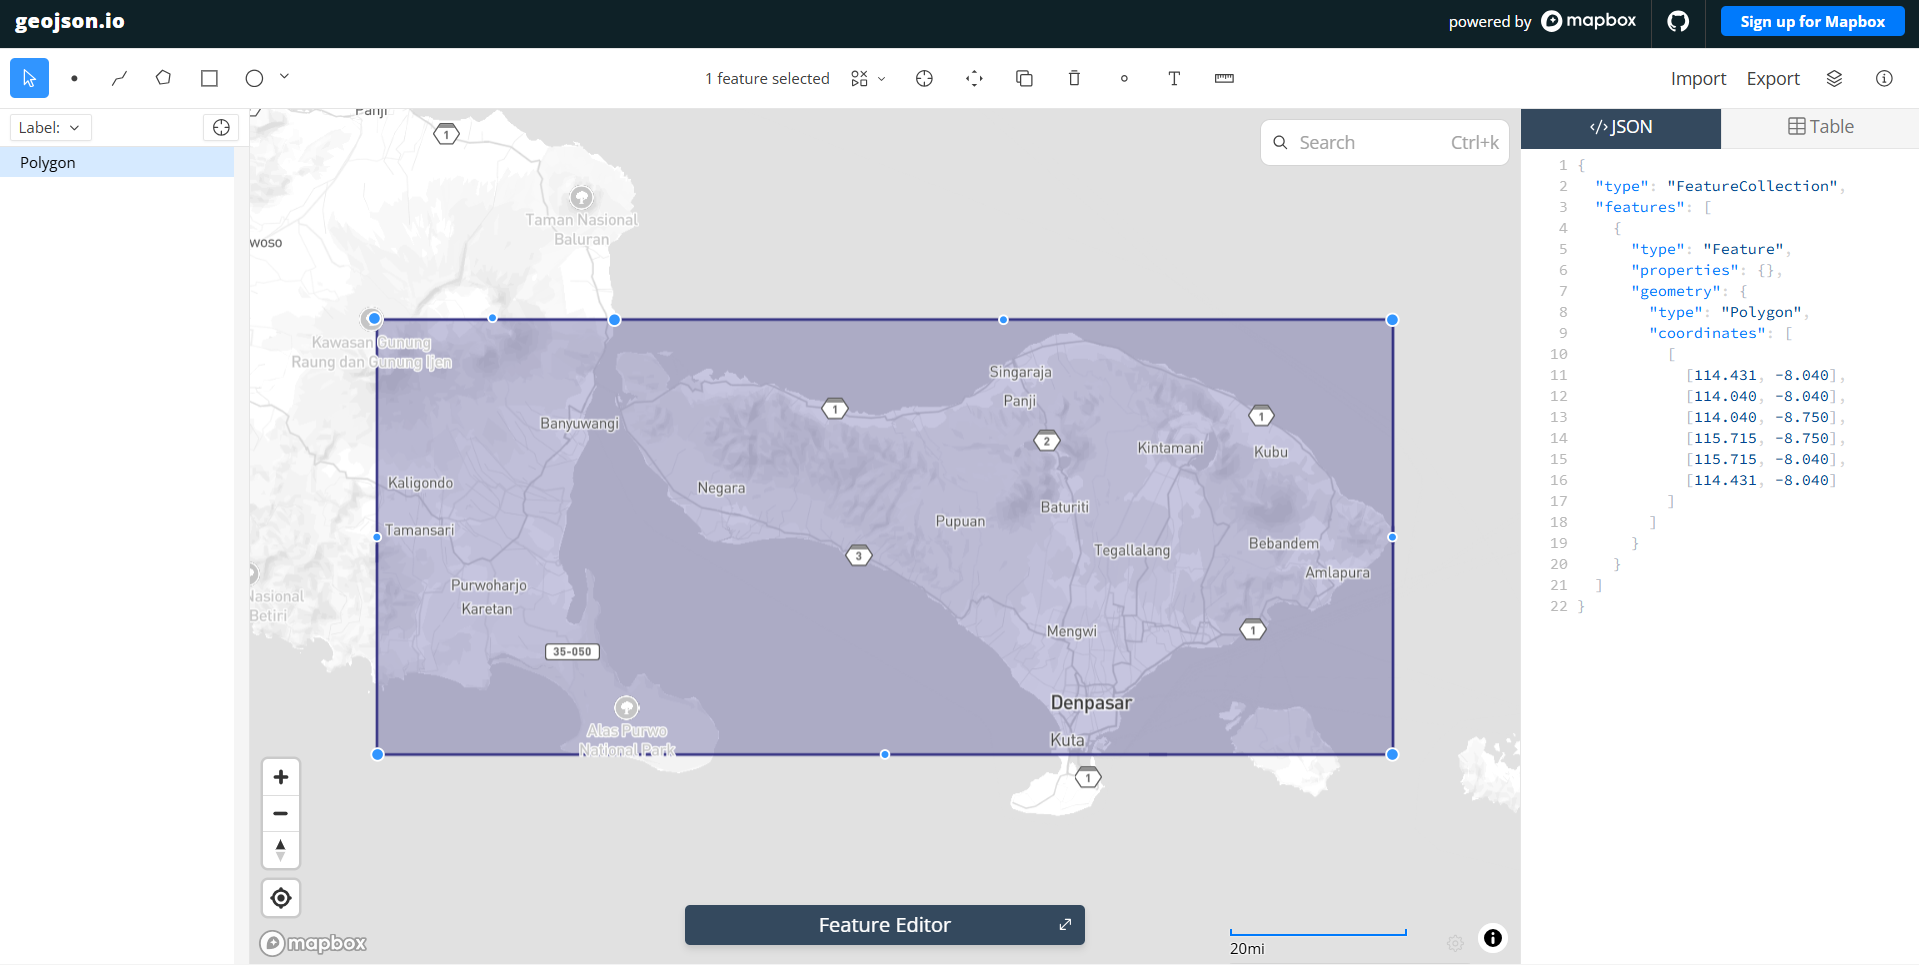

untuk memulai pengambilan data:

In [7]:
job = s5post.execute_batch(title="NO2 in Bali", outputfile="NO2Bali.nc")

0:00:00 Job 'j-2606030345324555accf5350590392f9': send 'start'
0:00:04 Job 'j-2606030345324555accf5350590392f9': queued (progress 0%)
0:00:09 Job 'j-2606030345324555accf5350590392f9': queued (progress 0%)
0:00:16 Job 'j-2606030345324555accf5350590392f9': queued (progress 0%)
0:00:24 Job 'j-2606030345324555accf5350590392f9': queued (progress 0%)
0:00:33 Job 'j-2606030345324555accf5350590392f9': queued (progress 0%)
0:00:46 Job 'j-2606030345324555accf5350590392f9': running (progress N/A)
0:01:01 Job 'j-2606030345324555accf5350590392f9': running (progress N/A)
0:01:21 Job 'j-2606030345324555accf5350590392f9': running (progress N/A)
0:01:45 Job 'j-2606030345324555accf5350590392f9': running (progress N/A)
0:02:15 Job 'j-2606030345324555accf5350590392f9': running (progress N/A)
0:02:52 Job 'j-2606030345324555accf5350590392f9': running (progress N/A)
0:03:39 Job 'j-2606030345324555accf5350590392f9': running (progress N/A)
0:04:37 Job 'j-2606030345324555accf5350590392f9': running (progress N/A

Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman

https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2



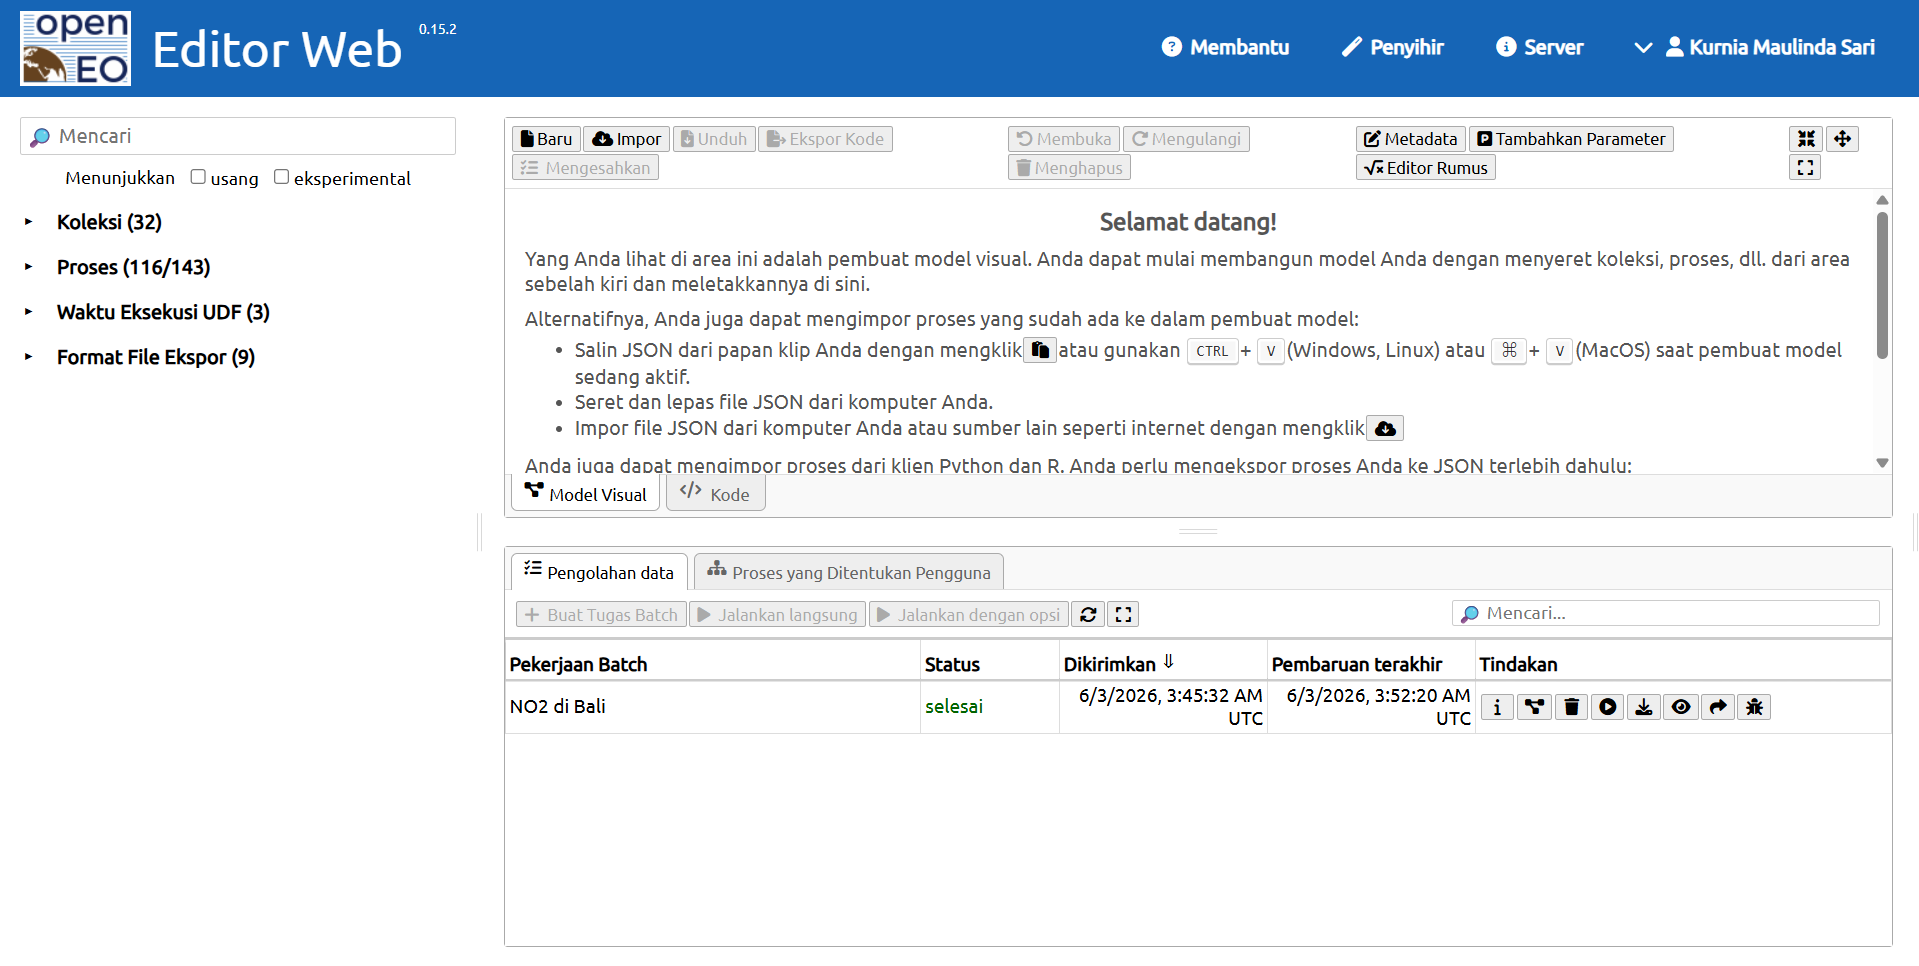

Setelah kita mengambil data, data bisa diunduh di

 https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2

File akan berbentuk .nc.

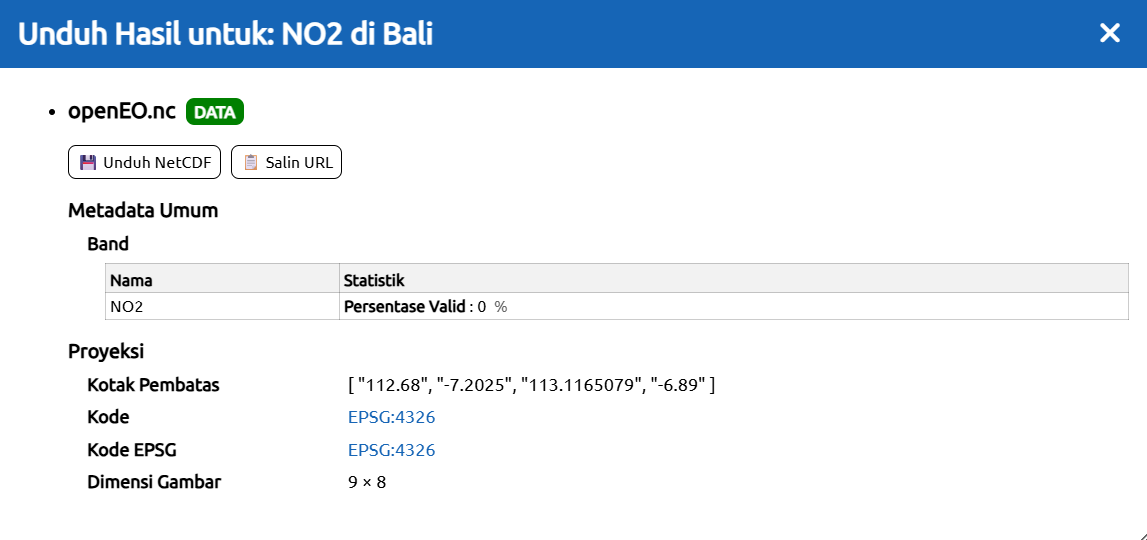

### 2. Preproccessing data

Saving openEO.nc to openEO.nc
        date  NO2_mean
0 2023-10-01  0.000029
1 2023-10-02  0.000022
2 2023-10-03  0.000026
3 2023-10-04  0.000016
4 2023-10-05  0.000018
5 2023-10-06  0.000023
6 2023-10-07  0.000017
7 2023-10-08  0.000021
8 2023-10-09  0.000022
9 2023-10-10  0.000029


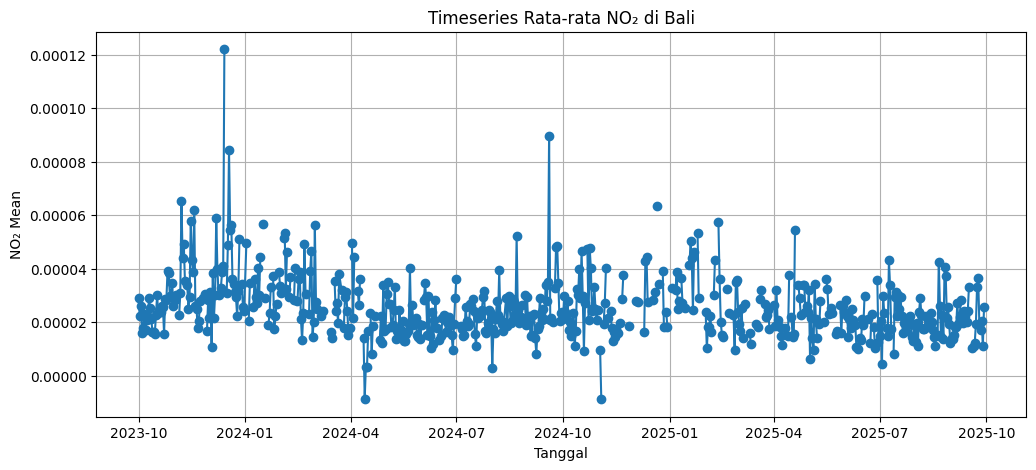

In [19]:
import netCDF4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload file NetCDF
uploaded = files.upload()
file_path = list(uploaded.keys())[0]  # ambil file yang dipilih

# Load file NetCDF
ds = netCDF4.Dataset(file_path)

# Ambil variabel NO2 dan waktu
no2 = ds.variables["NO2"][:]  # shape (time, lat, lon)
time = ds.variables["t"][:]

# Konversi waktu jika ada atribut units
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

# Konversi cftime ke datetime standar untuk Matplotlib
dates_dt = [pd.to_datetime(d.isoformat()) for d in dates]

# Hitung rata-rata NO2 per waktu (rata-rata seluruh grid)
no2_mean = np.mean(no2, axis=(1, 2))

# Buat DataFrame timeseries
df_no2 = pd.DataFrame({
    "date": dates_dt,
    "NO2_mean": no2_mean
})

# Tampilkan 10 data pertama
print(df_no2.head(10))

# Plot timeseries NO2
plt.figure(figsize=(12, 5))
plt.plot(df_no2["date"], df_no2["NO2_mean"], marker='o')
plt.title("Timeseries Rata-rata NO₂ di Bali")
plt.xlabel("Tanggal")
plt.ylabel("NO₂ Mean")
plt.grid(True)
plt.show()

Melihat 10 data pertama:

In [76]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[3.770179318962619e-05 4.4227883336134255e-05 2.893842975026928e-05
  2.7030169803765602e-05 2.3806940589565784e-05 2.586452137620654e-05
  1.6022562704165466e-05 9.385486009705346e-06]
 [3.770179318962619e-05 3.1096213206183165e-05 3.226231274311431e-05
  2.7030169803765602e-05 2.2647607693215832e-05 3.680306326714344e-05
  1.6022562704165466e-05 3.747334631043486e-05]
 [2.7158148441230878e-05 3.1096213206183165e-05 4.294700556783937e-05
  2.0787138055311516e-05 2.2647607693215832e-05 3.6170044040773064e-05
  2.544464950915426e-05 2.3946160581544973e-05]
 [2.9651806471520104e-05 3.772687341552228e-05 4.294700556783937e-05
  5.6563803809694946e-05 4.394538700580597e-05 3.6170044040773064e-05
  6.348737952066585e-05 3.904499681084417e-05]
 [2.9651806471520104e-05 4.1052295273402706e-05 -- 5.6563803809694946e-05
  -- -- 6.348737952066585e-05 --]
 [3.303916673758067e-05 4.1052295273402706e-05 1.2694688848569058e-05 --
  -- -- -- --]
 [1.5709914805484004e-05 3.2586256

Dalam satu hari terdapat banyak data NO₂ sehingga dilakukan perataan menjadi satu nilai per waktu. Namun, data tersebut masih memiliki missing value yang perlu ditangani sebelum analisis.

Mengatasi Missing Value menggunakan metode Interpolasi Linear. Menggunakan code di bawah ini missing value yang terdapat pada data NO2 akan diisi secara otomatis menggunakan metode Interpolasi Linear.

In [65]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)

no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()


Missing value pada data NO₂ kemudian diisi secara otomatis menggunakan metode interpolasi linear, yaitu dengan memperkirakan nilai berdasarkan pola data di sekitarnya sehingga data menjadi lebih lengkap dan kontinu.

In [23]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

Setelah itu kita akan membentuk data menjadi DataFrame dan disimpan sebagai file CSV untuk analisis selanjutnya.

In [45]:
!pip install netCDF4

import netCDF4
import numpy as np
import pandas as pd
from google.colab import files

uploaded = files.upload()

file_path = "/content/openEO.nc"   # ⚠️ sesuaikan nama file kamu
ds = netCDF4.Dataset(file_path)

print("📦 Variabel dalam file:")
print(ds.variables.keys())

var_names = list(ds.variables.keys())
print("Semua variabel:", var_names)

# biasanya variabel terakhir = data NO2
no2 = ds.variables[var_names[-1]][:]

# ambil waktu (coba 't' atau 'time')
if "t" in ds.variables:
    time = ds.variables["t"][:]
    time_units = ds.variables["t"].units
elif "time" in ds.variables:
    time = ds.variables["time"][:]
    time_units = ds.variables["time"].units
else:
    time = np.arange(no2.shape[0])
    time_units = None

try:
    dates = netCDF4.num2date(time, units=time_units)
except:
    dates = time

print(type(no2))
print(len(no2))          # waktu
print(len(no2[0]))       # lat
print(len(no2[0][0]))    # lon
print("Contoh nilai:", no2[0][0][0])

if hasattr(no2, "filled"):
    no2_filled = no2.filled(0)
else:
    no2_filled = no2.copy()

for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(
            method='linear',
            limit_direction='both'
        ).to_numpy()

new_dates = []
new_no2 = []

for i in range(len(dates)):
    try:
        new_date = dates[i].strftime('%Y-%m-%d')
    except:
        new_date = str(dates[i])

    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

print(df.head())

file_csv = "NO2_Bali_timeseries.csv"
df.to_csv(file_csv, index=False)

print("✅ File berhasil disimpan:", file_csv)

files.download(file_csv)

Saving openEO.nc to openEO (2).nc
📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
Semua variabel: ['t', 'x', 'y', 'crs', 'NO2']
<class 'numpy.ma.MaskedArray'>
725
9
8
Contoh nilai: 3.7701793e-05
         date       NO2
0  2023-10-01  0.000027
1  2023-10-02  0.000024
2  2023-10-03  0.000024
3  2023-10-04  0.000021
4  2023-10-05  0.000021
✅ File berhasil disimpan: NO2_Bali_timeseries.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Pengecekan Missing Value data harian pada CSV.

Setelah data disimpan dalam bentuk CSV, dilakukan pengecekan untuk memastikan data time series harian sudah lengkap. Pengecekan ini bertujuan melihat apakah terdapat tanggal yang hilang menggunakan kode di bawah ini:


In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Bali_timeseries.csv")

df['date'] = pd.to_datetime(df['date'])

start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 6
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


Ditemukan 6 hari data yang hilang pada time series. Untuk mengatasinya, missing value tersebut kembali diisi menggunakan metode interpolasi linear agar data menjadi lengkap dan tetap mengikuti pola yang ada.

In [77]:
import pandas as pd

df = pd.read_csv("NO2_Bali_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

print("\nContoh data:")
print(df.head())

print("\nInfo dataset:")
print(df.info())

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')

Contoh data:
        date       NO2
0 2023-10-01  0.000027
1 2023-10-02  0.000024
2 2023-10-03  0.000024
3 2023-10-04  0.000021
4 2023-10-05  0.000021

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    731 non-null    datetime64[ns]
 1   NO2     731 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.6 KB
None


Sudah tidak ada missing value harian, sudah tidak ada lagi missing value. Data yang dihasilkan memiliki dua kolom, yaitu kolom tanggal (date) dan kolom nilai konsentrasi NO₂ yang telah dirata-ratakan.


Setelah proses interpolasi untuk mengisi missing value, langkah berikutnya adalah melakukan deteksi outlier menggunakan metode IQR untuk mengidentifikasi nilai yang menyimpang dari data.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 14
         date       NO2
45 2023-11-15  0.000051
46 2023-11-16  0.000044
48 2023-11-18  0.000051
67 2023-12-07  0.000047
68 2023-12-08  0.000045


Untuk men-visualisasi outlier:

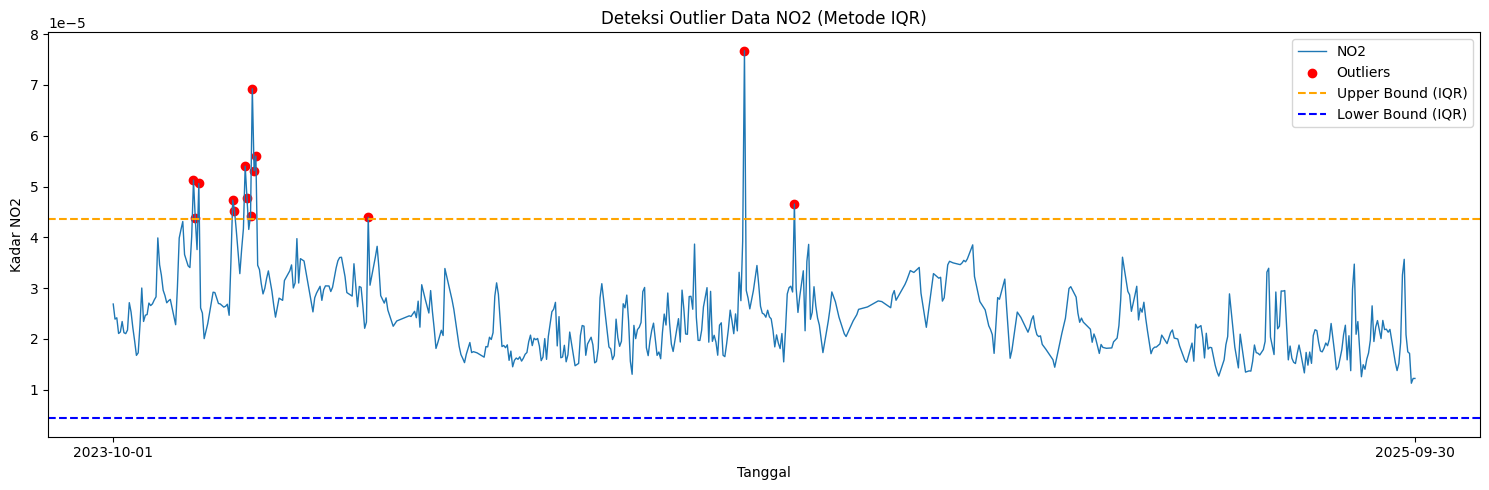

In [73]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Selanjutnya, data outlier akan dihapus. Karena data yang digunakan merupakan data time series, maka nilai outlier yang dihapus tersebut akan digantikan kembali menggunakan metode interpolasi linear.

In [50]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 14
Jumlah missing setelah interpolasi: 0


Visualisasi data setelah proses penghapusan outlier dan pengisian kembali nilai yang hilang menggunakan metode interpolasi linear

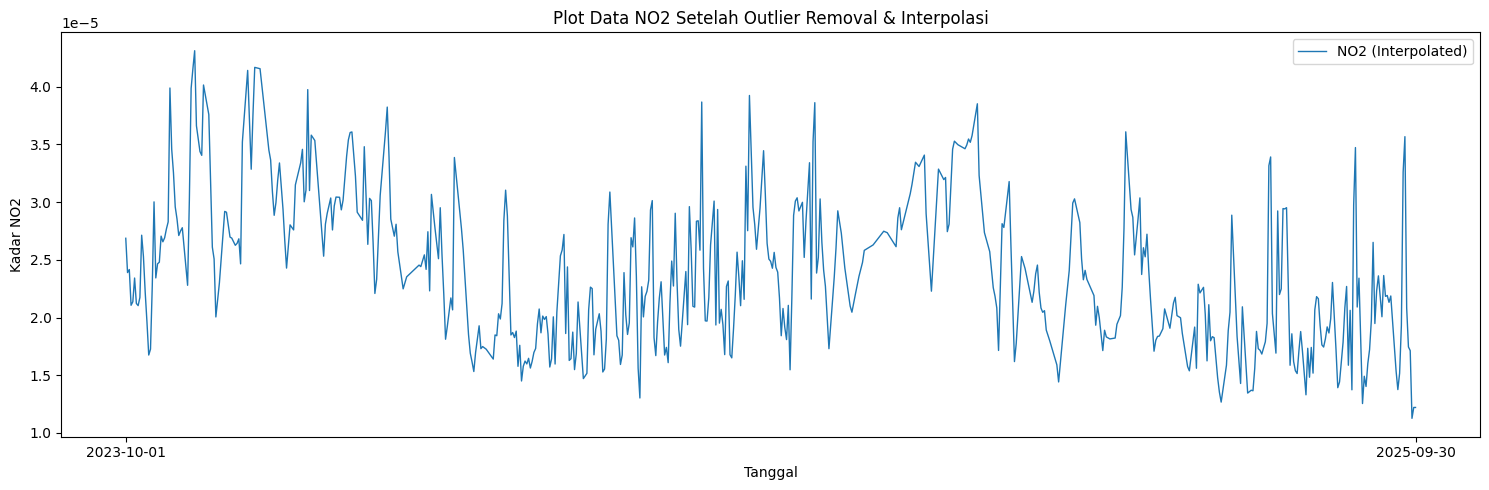

In [51]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

### 3. Modeling menggunakan KNN Regression
Dengan data time series kadar NO₂ harian di daerah Bali, dilakukan proses prediksi kadar NO₂ untuk satu hari ke depan. Pada tahap ini, data diubah untuk menganalisis hubungan antara nilai pada suatu hari dengan beberapa hari sebelumnya. Selain itu, dilakukan juga pengujian untuk mengetahui apakah penambahan jumlah hari sebelumnya (lag) dapat meningkatkan performa model.

#### a. Uji Korelasi Data
Sebelum proses pemodelan dilakukan, data awal masih bersifat unsupervised karena belum memiliki label. Oleh karena itu, data terlebih dahulu diubah menjadi bentuk supervised learning. Setelah itu, dilakukan uji korelasi antara fitur dan target (t).

Pada tahap ini, fitur yang digunakan adalah nilai NO₂ dari 30 hari sebelumnya (t-30, t-29, …, t-1), sedangkan target atau label adalah nilai pada hari ke-t.

In [74]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("NO2_Bali_interpolated.csv")

scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # fitur lag
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # target
    df_supervised['NO2(t)'] = data

    # hapus NaN
    df_supervised.dropna(inplace=True)

    return df_supervised

supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

print("Korelasi antara lag dan NO2(t):\n")
print(correlations)

Korelasi antara lag dan NO2(t):

NO2(t-30)    0.442305
NO2(t-29)    0.454453
NO2(t-28)    0.475321
NO2(t-27)    0.411415
NO2(t-26)    0.381489
NO2(t-25)    0.368746
NO2(t-24)    0.353040
NO2(t-23)    0.364877
NO2(t-22)    0.372361
NO2(t-21)    0.380395
NO2(t-20)    0.350779
NO2(t-19)    0.342422
NO2(t-18)    0.312533
NO2(t-17)    0.283250
NO2(t-16)    0.288271
NO2(t-15)    0.292097
NO2(t-14)    0.311898
NO2(t-13)    0.327056
NO2(t-12)    0.341676
NO2(t-11)    0.374011
NO2(t-10)    0.397309
NO2(t-9)     0.419212
NO2(t-8)     0.455895
NO2(t-7)     0.462417
NO2(t-6)     0.460079
NO2(t-5)     0.491438
NO2(t-4)     0.523747
NO2(t-3)     0.593804
NO2(t-2)     0.675922
NO2(t-1)     0.796428
dtype: float64


Skala nilai korelasi berada pada rentang -1 hingga 1. Berdasarkan hasil uji korelasi, fitur yang memiliki hubungan cukup kuat dengan NO₂(t) adalah yang memiliki nilai korelasi di atas 0.5, yaitu NO₂(t-4) sampai NO₂(t-1). Oleh karena itu, fitur-fitur tersebut digunakan dalam proses pemodelan KNN Regression.

#### b. Normalisasi Data

Karena menggunakan model KNN Regression, data perlu dinormalisasi terlebih dahulu menggunakan metode Min-Max Scaler agar seluruh fitur berada pada skala yang sama.


In [55]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

df = pd.read_csv("NO2_Bali_interpolated.csv")

# normalisasi
scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

print("Data setelah normalisasi:\n")
print(df.head())

print("\nInfo dataset:\n")
df.info()

Data setelah normalisasi:

         date       NO2  NO2_scaled
0  2023-10-01  0.000027    0.238203
1  2023-10-02  0.000024    0.192840
2  2023-10-03  0.000024    0.196854
3  2023-10-04  0.000021    0.149560
4  2023-10-05  0.000021    0.154247

Info dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        731 non-null    object 
 1   NO2         731 non-null    float64
 2   NO2_scaled  731 non-null    float64
dtypes: float64(2), object(1)
memory usage: 17.3+ KB


#### c. Mengubah Data

Pada tahap ini, data diubah dari sebelumnya menggunakan 2 fitur menjadi 5 fitur, yaitu 4 hari sebelumnya (t-4, t-3, t-2, t-1) sebagai fitur dan nilai pada hari ke-t sebagai label. Perubahan ini dilakukan berdasarkan hasil uji korelasi, di mana keempat lag tersebut memiliki nilai korelasi terbaik (di atas 0.5).

Selain itu, juga dibuat dataset dengan 10 hari sebelumnya untuk membandingkan apakah penambahan jumlah lag dapat meningkatkan performa model.

In [56]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.238203  0.192840  0.196854  0.149560  0.154247
5    0.192840  0.196854  0.149560  0.154247  0.185625
6    0.196854  0.149560  0.154247  0.185625  0.152010
7    0.149560  0.154247  0.185625  0.152010  0.149143
8    0.154247  0.185625  0.152010  0.149143  0.159907
..        ...       ...       ...       ...       ...
726  0.123092  0.325742  0.372653  0.145997  0.094458
727  0.325742  0.372653  0.145997  0.094458  0.089599
728  0.372653  0.145997  0.094458  0.089599  0.000000
729  0.145997  0.094458  0.089599  0.000000  0.014405
730  0.094458  0.089599  0.000000  0.014405  0.014405

[727 rows x 5 columns]
(727, 5)


Untuk membuat data dengan 10 hari sebelumnya, cukup mengubah parameter n_lag pada kode di bawah ini.

In [57]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.238203  0.192840  0.196854  0.149560  0.154247  0.185625  0.152010   
11    0.192840  0.196854  0.149560  0.154247  0.185625  0.152010  0.149143   
12    0.196854  0.149560  0.154247  0.185625  0.152010  0.149143  0.159907   
13    0.149560  0.154247  0.185625  0.152010  0.149143  0.159907  0.242292   
14    0.154247  0.185625  0.152010  0.149143  0.159907  0.242292  0.214105   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.161874  0.128849  0.095824  0.062799  0.038033  0.059606  0.123092   
727   0.128849  0.095824  0.062799  0.038033  0.059606  0.123092  0.325742   
728   0.095824  0.062799  0.038033  0.059606  0.123092  0.325742  0.372653   
729   0.062799  0.038033  0.059606  0.123092  0.325742  0.372653  0.145997   
730   0.038033  0.059606  0.123092  0.325742  0.372653  0.145997  0.094458   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.149143  0.

#### d. Modeling dan Evaluation

Selanjutnya, kedua dataset yang telah dibuat kemudian digunakan untuk melatih model KNN Regression.


In [58]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):

    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.065457
R² Score: 0.1399
MAPE: 61.0796%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.067596
R² Score: 0.0888
MAPE: 64.6647%


Berdasarkan hasil evaluasi di atas, terlihat bahwa model dengan 4 hari sebelumnya memberikan performa yang lebih baik dibandingkan model dengan 10 hari sebelumnya, ditinjau dari nilai RMSE, R² Score, dan MAPE. Hasil ini menunjukkan bahwa penambahan jumlah lag tidak selalu meningkatkan performa model. Selanjutnya, dilakukan percobaan menggunakan 30 hari sebelumnya untuk melihat apakah penambahan lag yang lebih banyak dapat memperbaiki atau justru menurunkan kinerja model.


In [61]:
knn_30, y_test_30, y_pred_30 = train_knn(
    supervised_df30,
    "KNN - 30 Hari Sebelumnya"
)


=== KNN - 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.074653
R² Score: -0.0820
MAPE: 323446555785284.4375%


#### e. Plotting

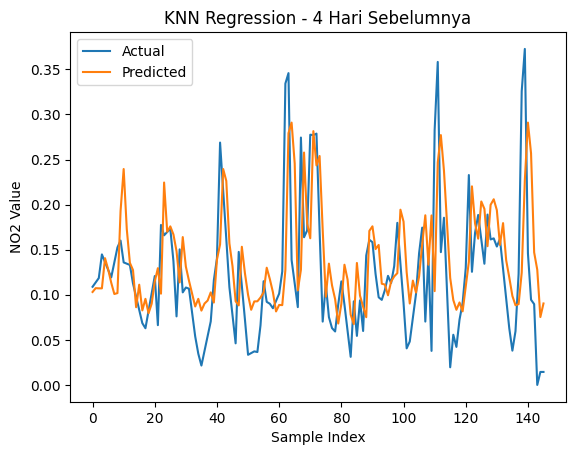

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

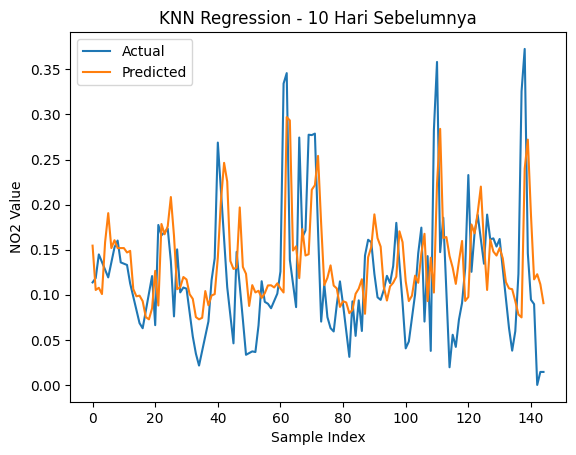

In [63]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

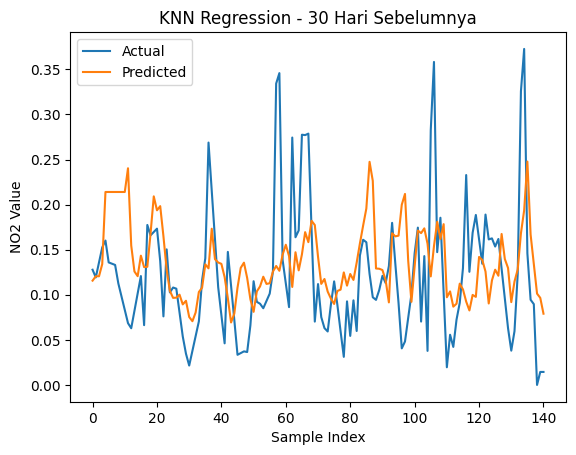

In [64]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()